# Eksperimen Machine Learning - Lufthi Arief Syabana
## Dataset: Smartphone Usage and Addiction Analysis

**Nama:** Lufthi Arief Syabana  
**Dataset:** Smartphone Usage and Addiction Analysis (7500 Rows)  
**Sumber:** [Kaggle - nalisha](https://www.kaggle.com/datasets/nalisha/smartphone-usage-and-addiction-analysis-dataset)  
**Task:** Binary Classification - Prediksi apakah pengguna smartphone tergolong *addicted* atau tidak

---
# **1. Perkenalan Dataset**

Dataset **Smartphone Usage and Addiction Analysis** berisi data perilaku penggunaan smartphone dari 7.500 pengguna. Dataset ini mencakup berbagai fitur seperti durasi penggunaan layar harian, jam bermain game, jam media sosial, kualitas tidur, tingkat stres, hingga dampak terhadap akademik/pekerjaan.

**Tujuan Analisis:**  
Memprediksi apakah seorang pengguna smartphone tergolong *addicted* (`addicted_label = 1`) atau tidak (`addicted_label = 0`) berdasarkan pola penggunaan smartphone mereka.

**Informasi Dataset:**
- **Jumlah baris:** 7.500
- **Jumlah kolom:** 16
- **Target variabel:** `addicted_label` (0 = Tidak Adiksi, 1 = Adiksi)
- **Tipe fitur:** Numerik kontinu, numerik diskrit, dan kategorikal

**Kolom-kolom dataset:**
| Kolom | Tipe | Deskripsi |
|---|---|---|
| transaction_id | String | ID transaksi unik (tidak relevan untuk model) |
| user_id | String | ID pengguna unik (tidak relevan untuk model) |
| age | Integer | Usia pengguna (18–35 tahun) |
| gender | String | Jenis kelamin (Male/Female/Other) |
| daily_screen_time_hours | Float | Total waktu layar harian (jam) |
| social_media_hours | Float | Jam penggunaan media sosial per hari |
| gaming_hours | Float | Jam bermain game per hari |
| work_study_hours | Float | Jam kerja/belajar per hari |
| sleep_hours | Float | Jam tidur per hari |
| notifications_per_day | Integer | Jumlah notifikasi per hari |
| app_opens_per_day | Integer | Jumlah pembukaan aplikasi per hari |
| weekend_screen_time | Float | Waktu layar di akhir pekan (jam) |
| stress_level | String | Tingkat stres (Low/Medium/High) |
| academic_work_impact | String | Dampak pada akademik/pekerjaan (Yes/No) |
| addiction_level | String | Level adiksi (Mild/Moderate/Severe) - memiliki missing values |
| addicted_label | Integer | Label target: 0 = Tidak Adiksi, 1 = Adiksi |

---
# **2. Import Library**

In [1]:
# Library standar
import os
import warnings
warnings.filterwarnings('ignore')

# Manipulasi data
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

# Evaluasi
from sklearn.model_selection import train_test_split

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Semua library berhasil diimport!')
print(f'   - NumPy versi     : {np.__version__}')
print(f'   - Pandas versi    : {pd.__version__}')

✅ Semua library berhasil diimport!
   - NumPy versi     : 2.0.2
   - Pandas versi    : 2.2.2


---
# **3. Memuat Dataset**

In [2]:
# Load dataset
# Jika menggunakan Google Colab, upload file terlebih dahulu atau mount Google Drive
# from google.colab import files
# uploaded = files.upload()

DATASET_PATH = '/content/smartphone_usage_raw.csv'

df = pd.read_csv(DATASET_PATH)

print('✅ Dataset berhasil dimuat!')
print(f'   - Jumlah baris  : {df.shape[0]:,}')
print(f'   - Jumlah kolom  : {df.shape[1]}')
print()
df.head()

✅ Dataset berhasil dimuat!
   - Jumlah baris  : 7,500
   - Jumlah kolom  : 16



,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.230,2.010,0.890,4.550,7.550,248,154,3.950,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.090,3.810,2.240,4.440,7.660,127,71,6.710,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.060,1.360,3.830,2.350,4.920,44,106,8.680,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.830,5.850,1.510,3.540,8.230,178,107,9.770,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.960,5.920,3.420,5.270,6.210,136,177,12.550,Low,No,Severe,1


In [3]:
# Tampilkan info dataset
print('=== INFO DATASET ===')
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  add

In [4]:
# Tampilkan statistik deskriptif
print('=== STATISTIK DESKRIPTIF ===')
df.describe(include='all')

=== STATISTIK DESKRIPTIF ===


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
count,7500,7500,7500.000,7500,7500.000,7500.000,7500.000,7500.000,7500.000,7500.000,7500.000,7500.000,7500,7500,6681,7500.000
unique,7500,7500,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2,3,NaN
top,TXN07500,U07500,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,No,Moderate,NaN
freq,1,1,NaN,2553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2560,3753,2874,NaN
mean,NaN,NaN,26.569,NaN,7.500,3.273,2.014,3.242,6.738,134.257,97.832,9.244,NaN,NaN,NaN,0.708
std,NaN,NaN,5.197,NaN,2.609,1.585,1.146,1.601,1.284,66.587,48.423,2.718,NaN,NaN,NaN,0.455
min,NaN,NaN,18.000,NaN,3.000,0.500,0.000,0.500,4.500,20.000,15.000,3.580,NaN,NaN,NaN,0.000
25%,NaN,NaN,22.000,NaN,5.220,1.910,1.020,1.850,5.630,76.000,55.000,6.960,NaN,NaN,NaN,0.000
50%,NaN,NaN,27.000,NaN,7.525,3.270,2.040,3.230,6.720,134.000,98.000,9.260,NaN,NaN,NaN,1.000
75%,NaN,NaN,31.000,NaN,9.810,4.630,2.990,4.640,7.840,191.000,140.000,11.540,NaN,NaN,NaN,1.000


---
# **4. Exploratory Data Analysis (EDA)**

Pada tahap EDA, kita akan memahami karakteristik dataset secara mendalam melalui:
1. Pengecekan distribusi variabel target
2. Distribusi fitur numerik
3. Distribusi fitur kategorikal
4. Analisis korelasi antar fitur
5. Pengecekan missing values
6. Pengecekan duplikasi data

## 4.1 Pengecekan Missing Values & Duplikasi

=== MISSING VALUES ===
                 Missing Count  Missing (%)
addiction_level            819       10.920


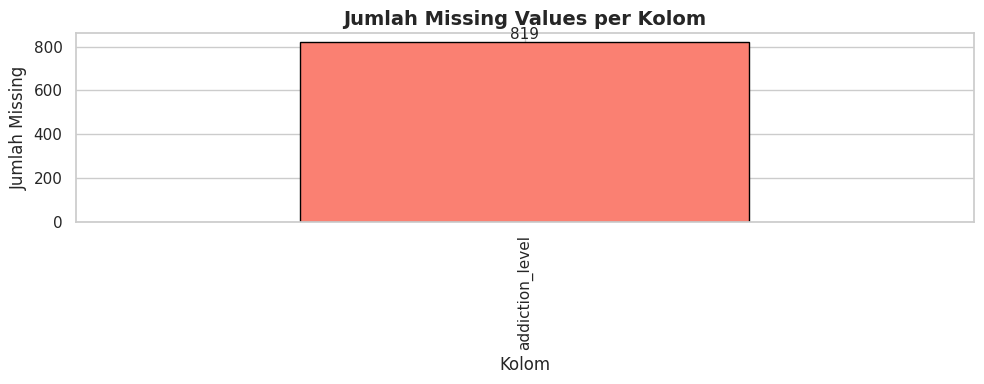

In [5]:
# Cek missing values
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).query('`Missing Count` > 0')

if missing_df.empty:
    print('Tidak ada missing values!')
else:
    print(missing_df)

# Visualisasi missing values
fig, ax = plt.subplots(figsize=(10, 4))
missing_all = df.isnull().sum()
missing_all[missing_all > 0].plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
ax.set_title('Jumlah Missing Values per Kolom', fontsize=14, fontweight='bold')
ax.set_xlabel('Kolom')
ax.set_ylabel('Jumlah Missing')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=100, bbox_inches='tight')
plt.show()

In [6]:
# Cek data duplikat
print('=== DATA DUPLIKAT ===')
duplicate_count = df.duplicated().sum()
print(f'Jumlah baris duplikat: {duplicate_count}')
if duplicate_count > 0:
    print('\nSample data duplikat:')
    print(df[df.duplicated()].head())

=== DATA DUPLIKAT ===
Jumlah baris duplikat: 0


## 4.2 Distribusi Variabel Target

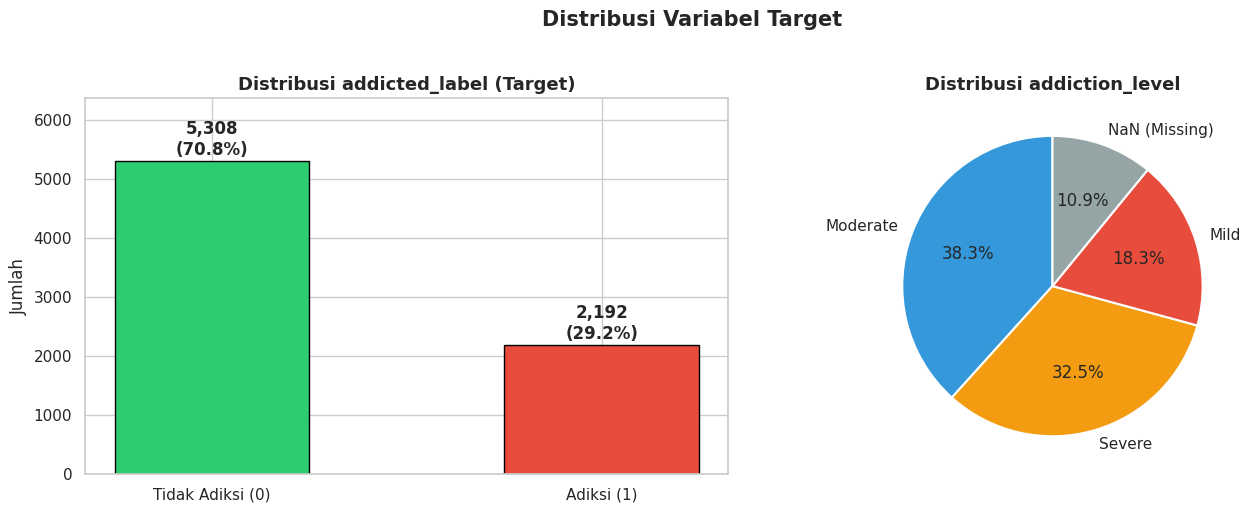


Class Imbalance Ratio: 2.42:1 (Adiksi:Tidak Adiksi)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: addicted_label
label_counts = df['addicted_label'].value_counts()
label_pct = df['addicted_label'].value_counts(normalize=True) * 100
colors_label = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Tidak Adiksi (0)', 'Adiksi (1)'], label_counts.values,
                   color=colors_label, edgecolor='black', width=0.5)
for bar, pct in zip(bars, label_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{bar.get_height():,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribusi addicted_label (Target)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
axes[0].set_ylim(0, label_counts.max() * 1.2)

# Plot 2: addiction_level
level_counts = df['addiction_level'].value_counts(dropna=False)
colors_level = ['#3498db', '#f39c12', '#e74c3c', '#95a5a6']
level_labels = [str(x) if str(x) != 'nan' else 'NaN (Missing)' for x in level_counts.index]
axes[1].pie(level_counts.values, labels=level_labels, autopct='%1.1f%%',
            colors=colors_level, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Distribusi addiction_level', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi Variabel Target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\nClass Imbalance Ratio: {label_counts[1]/label_counts[0]:.2f}:1 (Adiksi:Tidak Adiksi)')

## 4.3 Distribusi Fitur Numerik

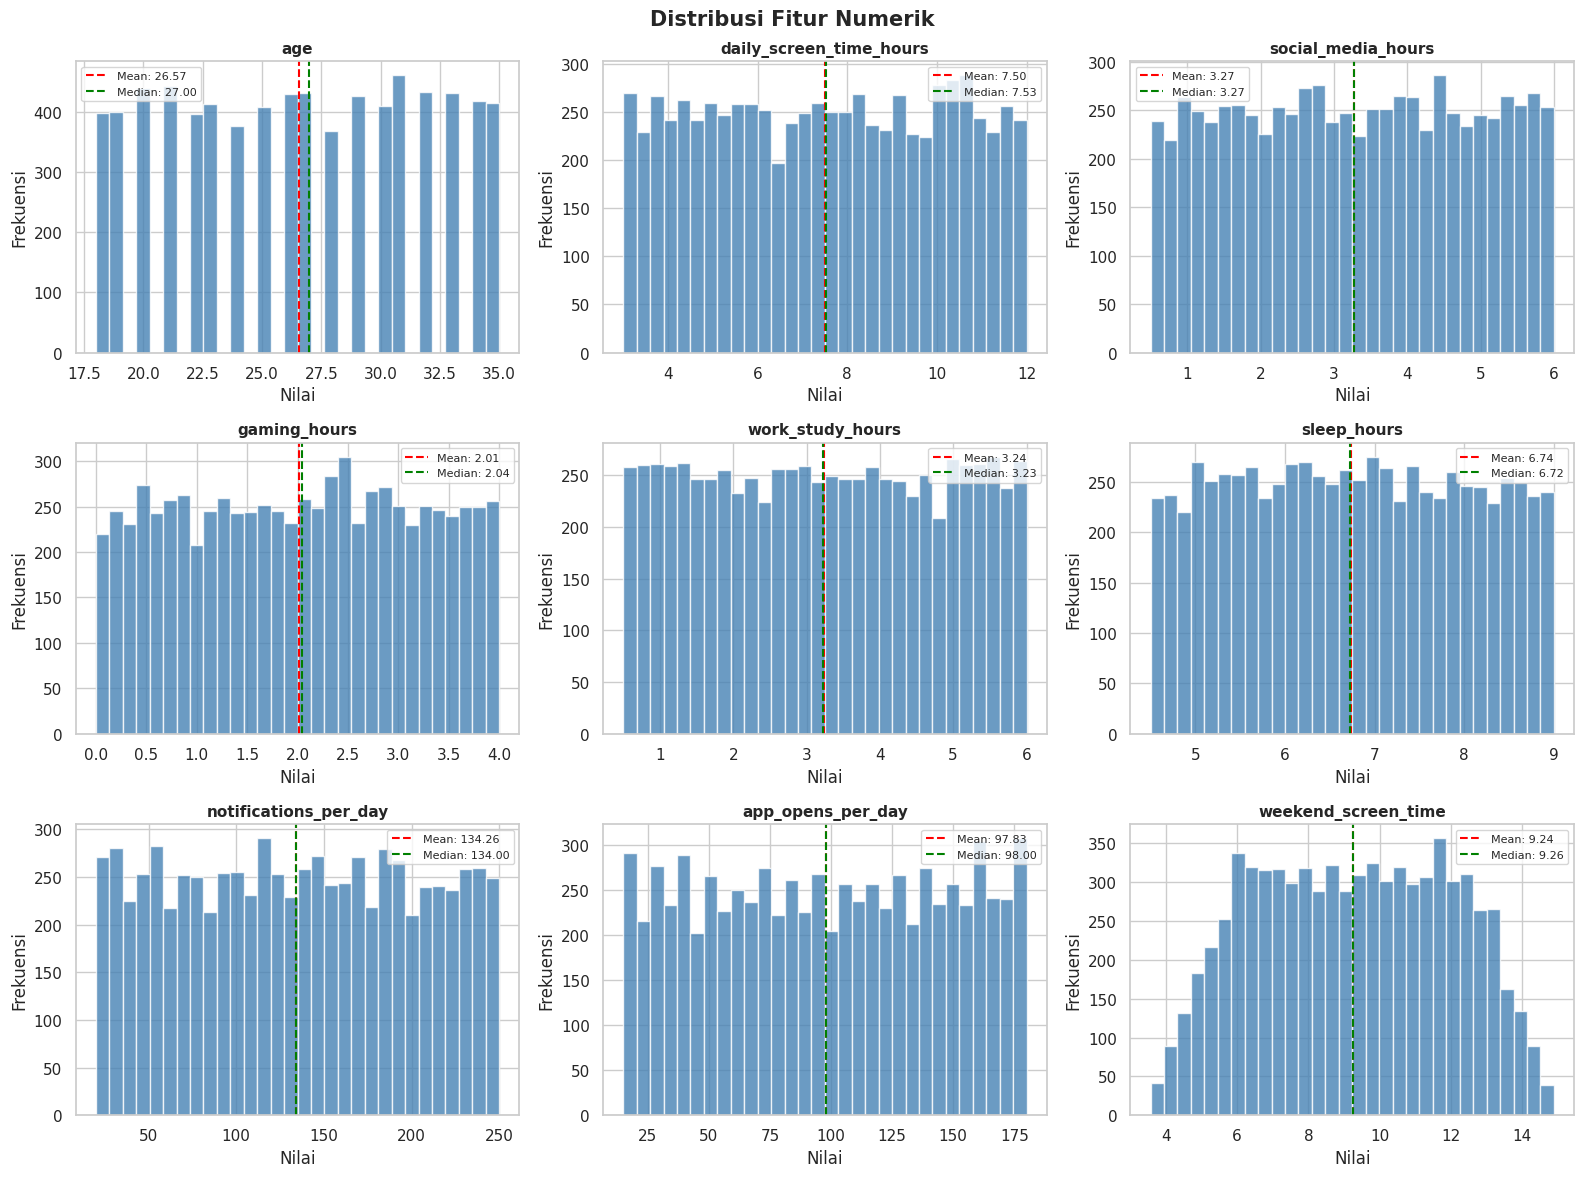

In [8]:
num_cols = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
            'work_study_hours', 'sleep_hours', 'notifications_per_day',
            'app_opens_per_day', 'weekend_screen_time']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

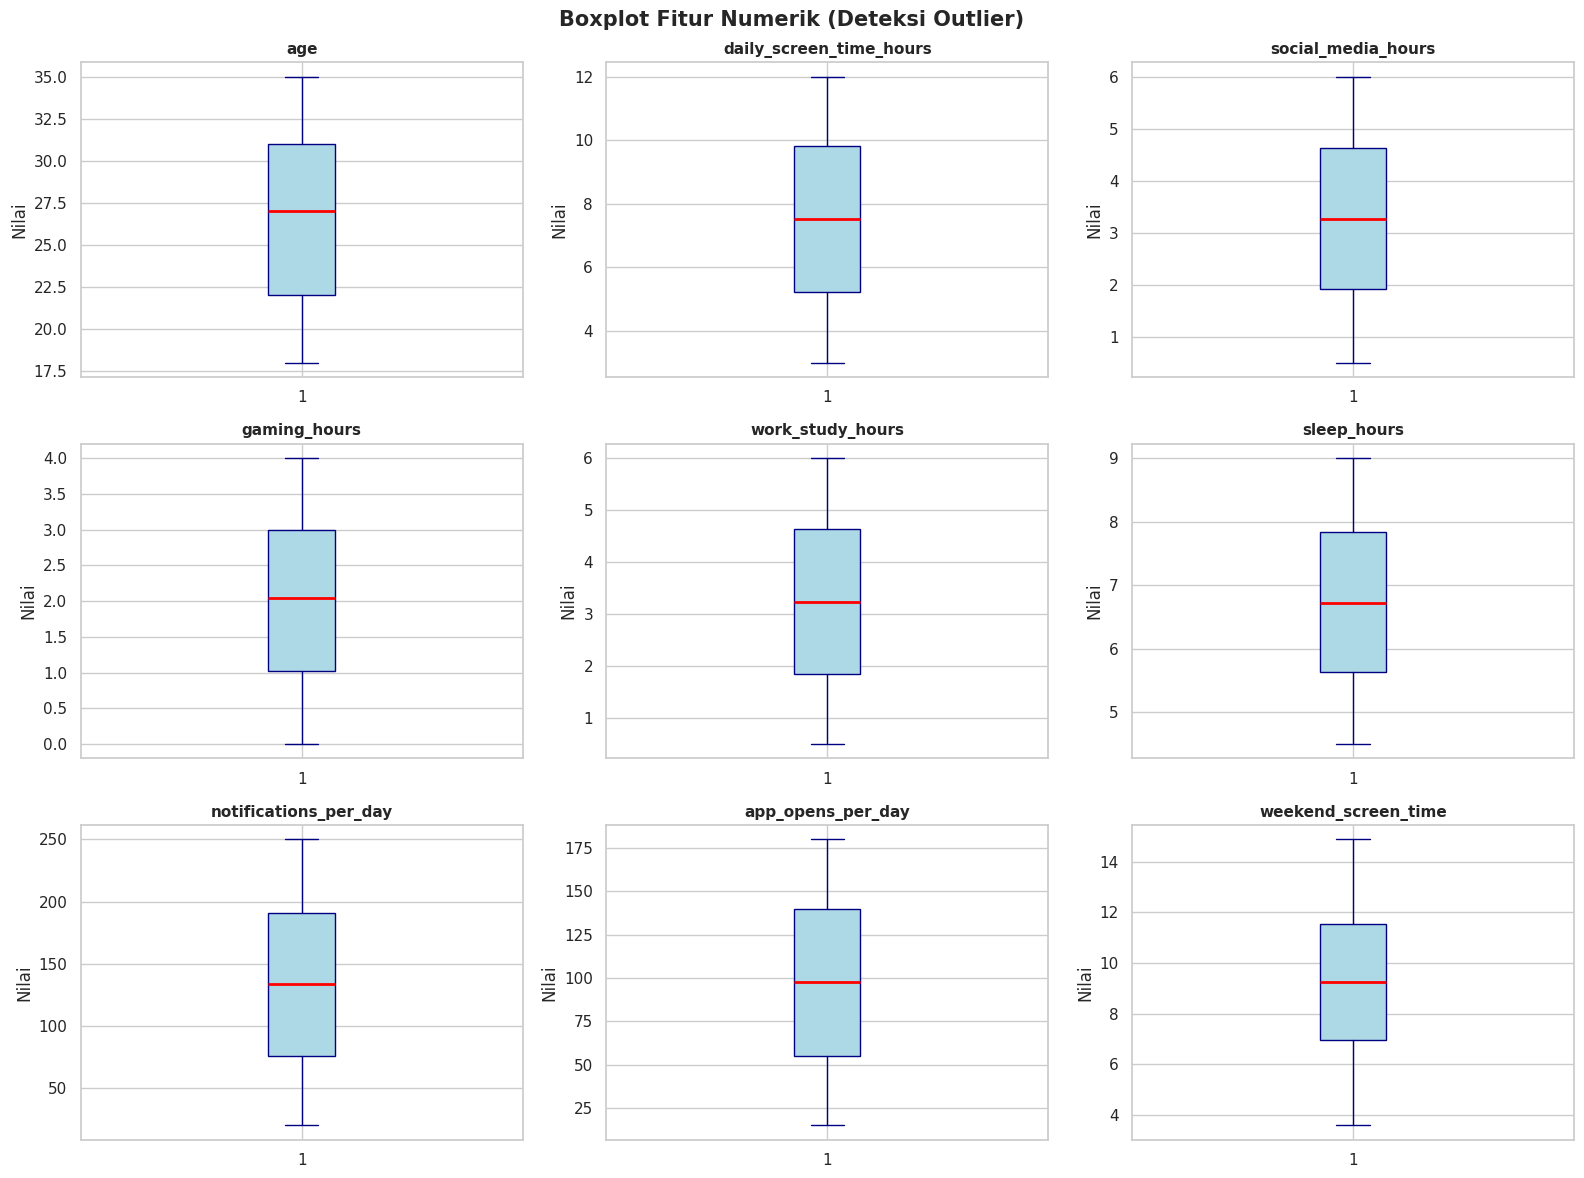

In [9]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='navy'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='navy'),
                   capprops=dict(color='navy'))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Nilai')

plt.suptitle('Boxplot Fitur Numerik (Deteksi Outlier)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_outlier.png', dpi=100, bbox_inches='tight')
plt.show()

## 4.4 Distribusi Fitur Kategorikal

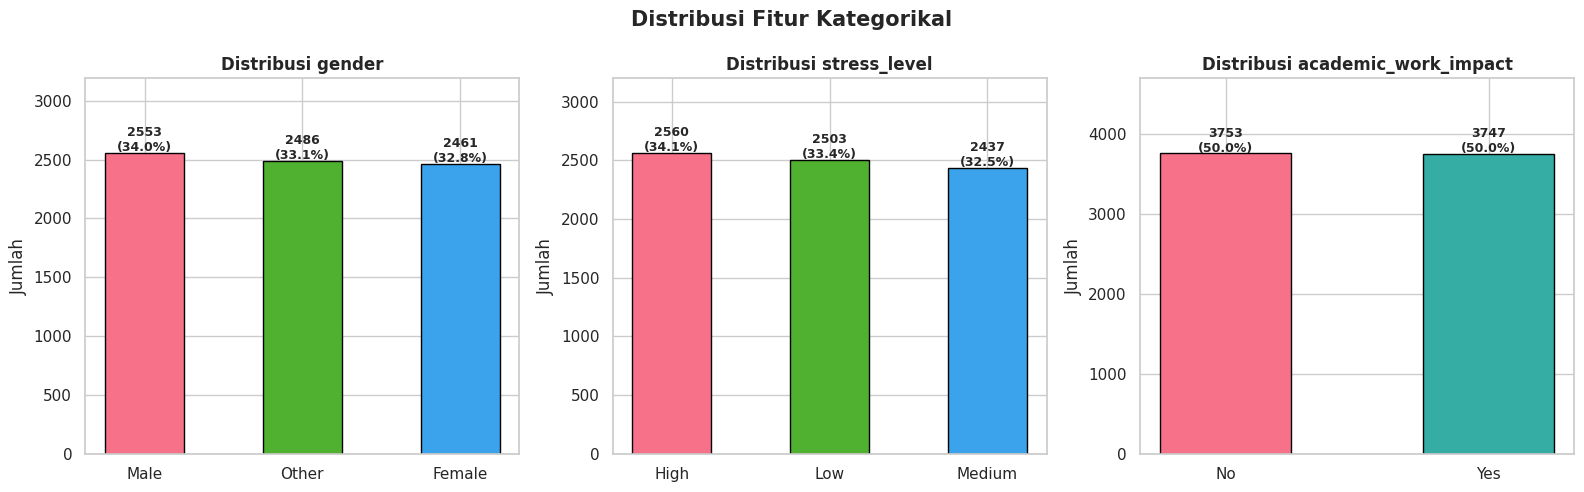

In [10]:
cat_cols = ['gender', 'stress_level', 'academic_work_impact']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values,
                       color=sns.color_palette('husl', len(counts)),
                       edgecolor='black', width=0.5)
    for bar in bars:
        pct = bar.get_height() / len(df) * 100
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                     f'{int(bar.get_height())}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Jumlah')
    axes[i].set_ylim(0, counts.max() * 1.25)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 4.5 Analisis Hubungan Fitur dengan Target

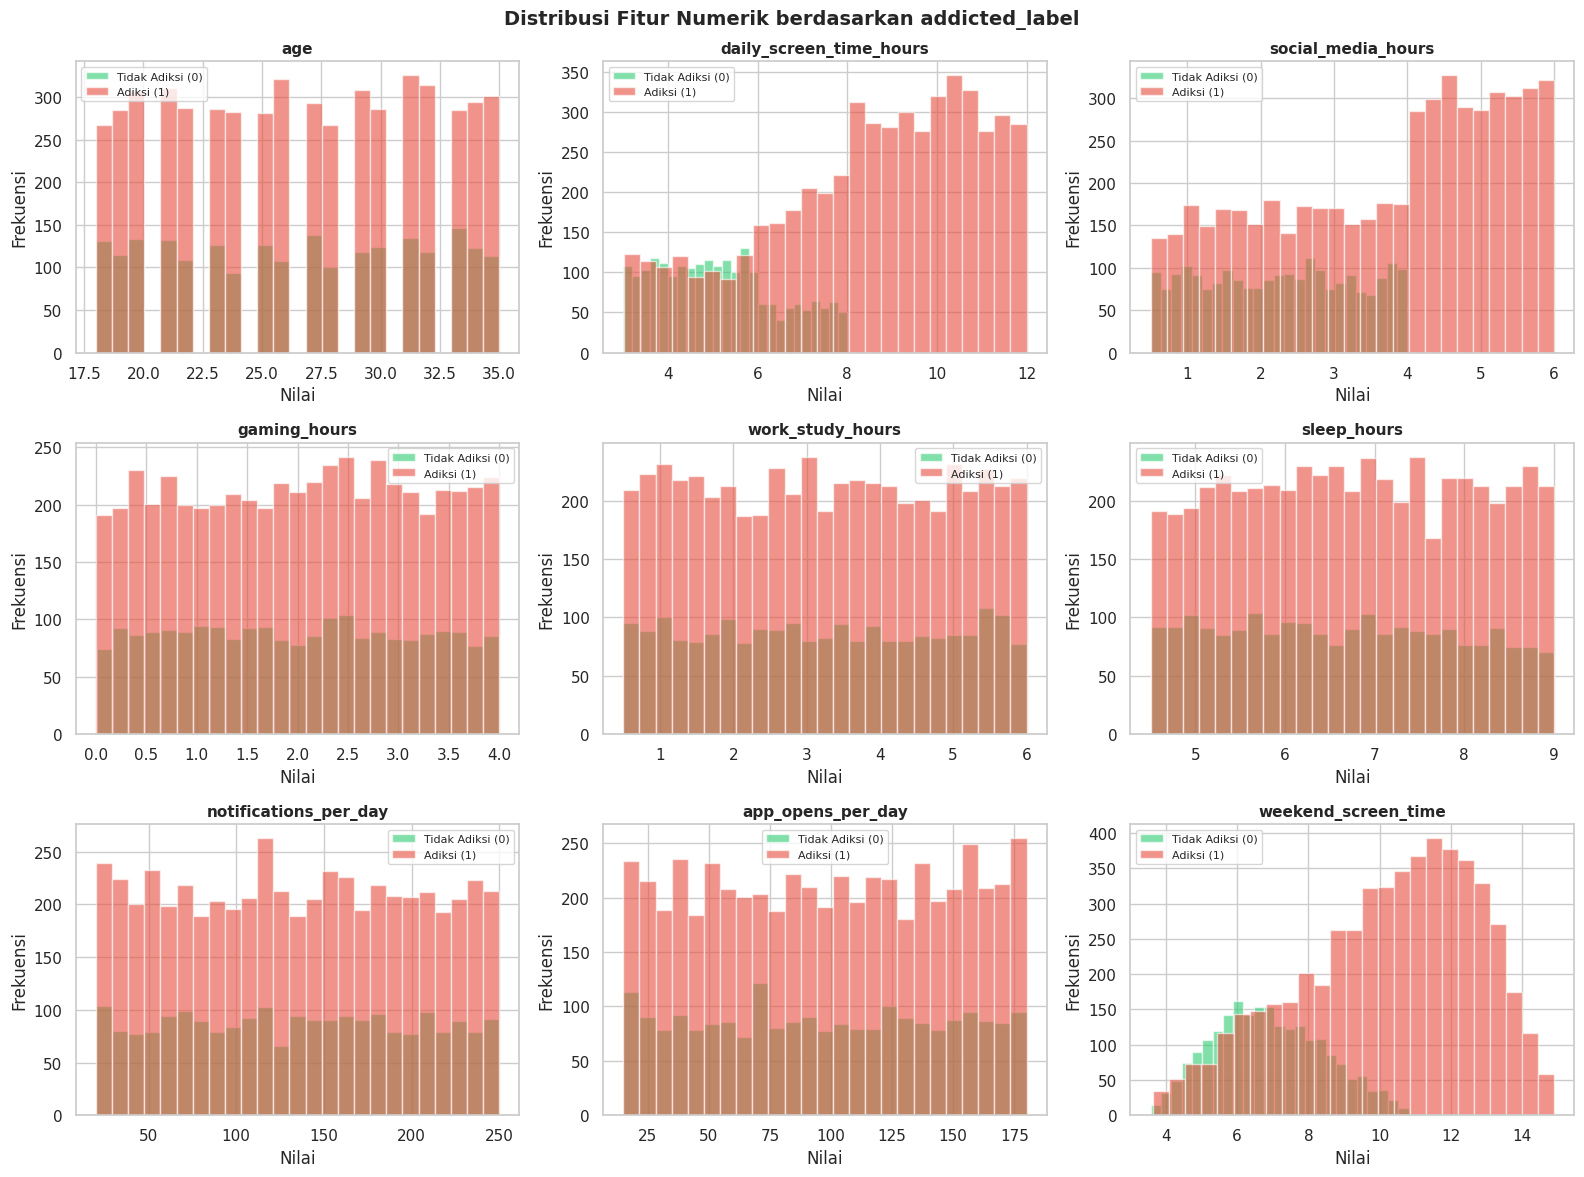

In [11]:
# Hubungan fitur numerik dengan target (addicted_label)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_0 = df[df['addicted_label'] == 0][col]
    data_1 = df[df['addicted_label'] == 1][col]
    axes[i].hist(data_0, bins=25, alpha=0.6, color='#2ecc71', label='Tidak Adiksi (0)', edgecolor='white')
    axes[i].hist(data_1, bins=25, alpha=0.6, color='#e74c3c', label='Adiksi (1)', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik berdasarkan addicted_label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_vs_target.png', dpi=100, bbox_inches='tight')
plt.show()

## 4.6 Heatmap Korelasi

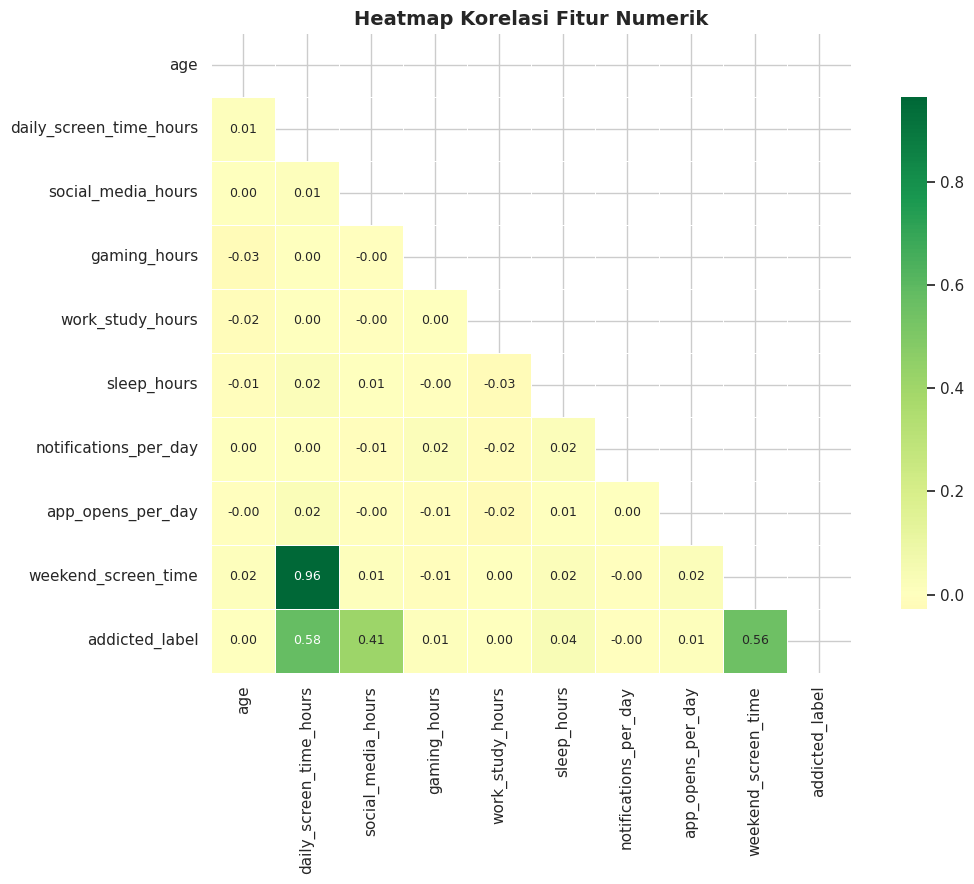


=== TOP KORELASI DENGAN addicted_label ===
daily_screen_time_hours    0.577
weekend_screen_time        0.555
social_media_hours         0.414
sleep_hours                0.035
app_opens_per_day          0.011
gaming_hours               0.008
age                        0.004
work_study_hours           0.001
notifications_per_day     -0.001


In [12]:
# Heatmap korelasi fitur numerik
corr_cols = num_cols + ['addicted_label']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 9})
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Top korelasi dengan target
print('\n=== TOP KORELASI DENGAN addicted_label ===')
print(corr_matrix['addicted_label'].drop('addicted_label').sort_values(ascending=False).to_string())

---
# **5. Data Preprocessing**

Berdasarkan EDA, berikut langkah-langkah preprocessing yang akan dilakukan:
1. **Drop kolom tidak relevan** (`transaction_id`, `user_id`)
2. **Menangani Missing Values** pada kolom `addiction_level` (imputasi dengan modus)
3. **Encoding Data Kategorikal** (Label Encoding untuk ordinal, One-Hot Encoding untuk nominal)
4. **Normalisasi Fitur Numerik** (StandardScaler)
5. **Split Data** (Train/Test 80:20)

## 5.1 Drop Kolom Tidak Relevan

In [13]:
df_processed = df.copy()

# Drop kolom ID yang tidak relevan untuk model
cols_to_drop = ['transaction_id', 'user_id']
df_processed = df_processed.drop(columns=cols_to_drop)

print(f'✅ Kolom {cols_to_drop} berhasil di-drop')
print(f'   Shape setelah drop: {df_processed.shape}')
print(f'   Kolom tersisa: {df_processed.columns.tolist()}')

✅ Kolom ['transaction_id', 'user_id'] berhasil di-drop
   Shape setelah drop: (7500, 14)
   Kolom tersisa: ['age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']


## 5.2 Menangani Missing Values

In [14]:
# Cek missing values sebelum penanganan
print('=== MISSING VALUES SEBELUM PENANGANAN ===')
print(df_processed.isnull().sum()[df_processed.isnull().sum() > 0])

# Imputasi addiction_level dengan modus (nilai yang paling sering muncul)
addiction_mode = df_processed['addiction_level'].mode()[0]
print(f'\nModus addiction_level: {addiction_mode}')
df_processed['addiction_level'] = df_processed['addiction_level'].fillna(addiction_mode)

print('\n=== MISSING VALUES SETELAH PENANGANAN ===')
print(df_processed.isnull().sum())
print('\n✅ Missing values berhasil ditangani!')

=== MISSING VALUES SEBELUM PENANGANAN ===
addiction_level    819
dtype: int64

Modus addiction_level: Moderate

=== MISSING VALUES SETELAH PENANGANAN ===
age                        0
gender                     0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
addiction_level            0
addicted_label             0
dtype: int64

✅ Missing values berhasil ditangani!


## 5.3 Encoding Data Kategorikal

In [15]:
# Label Encoding untuk fitur ordinal (memiliki urutan)
# stress_level: Low=0, Medium=1, High=2
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_processed['stress_level'] = df_processed['stress_level'].map(stress_map)
print('✅ Label Encoding stress_level:', stress_map)

# addiction_level: Mild=0, Moderate=1, Severe=2
addiction_map = {'Mild': 0, 'Moderate': 1, 'Severe': 2}
df_processed['addiction_level'] = df_processed['addiction_level'].map(addiction_map)
print('✅ Label Encoding addiction_level:', addiction_map)

# Label Encoding untuk academic_work_impact (binary)
academic_map = {'No': 0, 'Yes': 1}
df_processed['academic_work_impact'] = df_processed['academic_work_impact'].map(academic_map)
print('✅ Label Encoding academic_work_impact:', academic_map)

# One-Hot Encoding untuk gender (nominal, tidak ada urutan)
df_processed = pd.get_dummies(df_processed, columns=['gender'], prefix='gender', drop_first=False)
print('✅ One-Hot Encoding gender: gender_Female, gender_Male, gender_Other')

print(f'\nShape setelah encoding: {df_processed.shape}')
print(f'Kolom baru: {df_processed.columns.tolist()}')

✅ Label Encoding stress_level: {'Low': 0, 'Medium': 1, 'High': 2}
✅ Label Encoding addiction_level: {'Mild': 0, 'Moderate': 1, 'Severe': 2}
✅ Label Encoding academic_work_impact: {'No': 0, 'Yes': 1}
✅ One-Hot Encoding gender: gender_Female, gender_Male, gender_Other

Shape setelah encoding: (7500, 16)
Kolom baru: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label', 'gender_Female', 'gender_Male', 'gender_Other']


In [16]:
# Tampilkan sample setelah encoding
print('=== SAMPLE DATA SETELAH ENCODING ===')
df_processed.head()

=== SAMPLE DATA SETELAH ENCODING ===


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,gender_Female,gender_Male,gender_Other
0,21,3.230,2.010,0.890,4.550,7.550,248,154,3.950,1,1,1,0,False,True,False
1,24,5.090,3.810,2.240,4.440,7.660,127,71,6.710,1,1,1,0,False,False,True
2,31,6.060,1.360,3.830,2.350,4.920,44,106,8.680,2,0,0,0,False,False,True
3,32,7.830,5.850,1.510,3.540,8.230,178,107,9.770,2,1,1,1,False,False,True
4,25,9.960,5.920,3.420,5.270,6.210,136,177,12.550,0,0,2,1,False,True,False


## 5.4 Normalisasi Fitur Numerik

In [17]:
# Pisahkan fitur dan target sebelum normalisasi
TARGET_COL = 'addicted_label'
X = df_processed.drop(columns=[TARGET_COL])
y = df_processed[TARGET_COL]

print(f'Shape fitur (X) : {X.shape}')
print(f'Shape target (y): {y.shape}')
print(f'\nDistribusi target:\n{y.value_counts()}')

Shape fitur (X) : (7500, 15)
Shape target (y): (7500,)

Distribusi target:
addicted_label
1    5308
0    2192
Name: count, dtype: int64


In [18]:
# Normalisasi menggunakan StandardScaler hanya untuk kolom numerik kontinu
cols_to_scale = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
                 'work_study_hours', 'sleep_hours', 'notifications_per_day',
                 'app_opens_per_day', 'weekend_screen_time']

scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

print('✅ Normalisasi StandardScaler berhasil diterapkan!')
print(f'   Kolom yang dinormalisasi: {cols_to_scale}')
print(f'\nStatistik setelah normalisasi:')
print(X[cols_to_scale].describe().round(4))

✅ Normalisasi StandardScaler berhasil diterapkan!
   Kolom yang dinormalisasi: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']

Statistik setelah normalisasi:
           age  daily_screen_time_hours  social_media_hours  gaming_hours  \
count 7500.000                 7500.000            7500.000      7500.000   
mean     0.000                    0.000               0.000        -0.000   
std      1.000                    1.000               1.000         1.000   
min     -1.649                   -1.725              -1.750        -1.758   
25%     -0.879                   -0.874              -0.860        -0.868   
50%      0.083                    0.010              -0.002         0.022   
75%      0.853                    0.885               0.856         0.852   
max      1.622                    1.725               1.720         1.733   

       work_study_

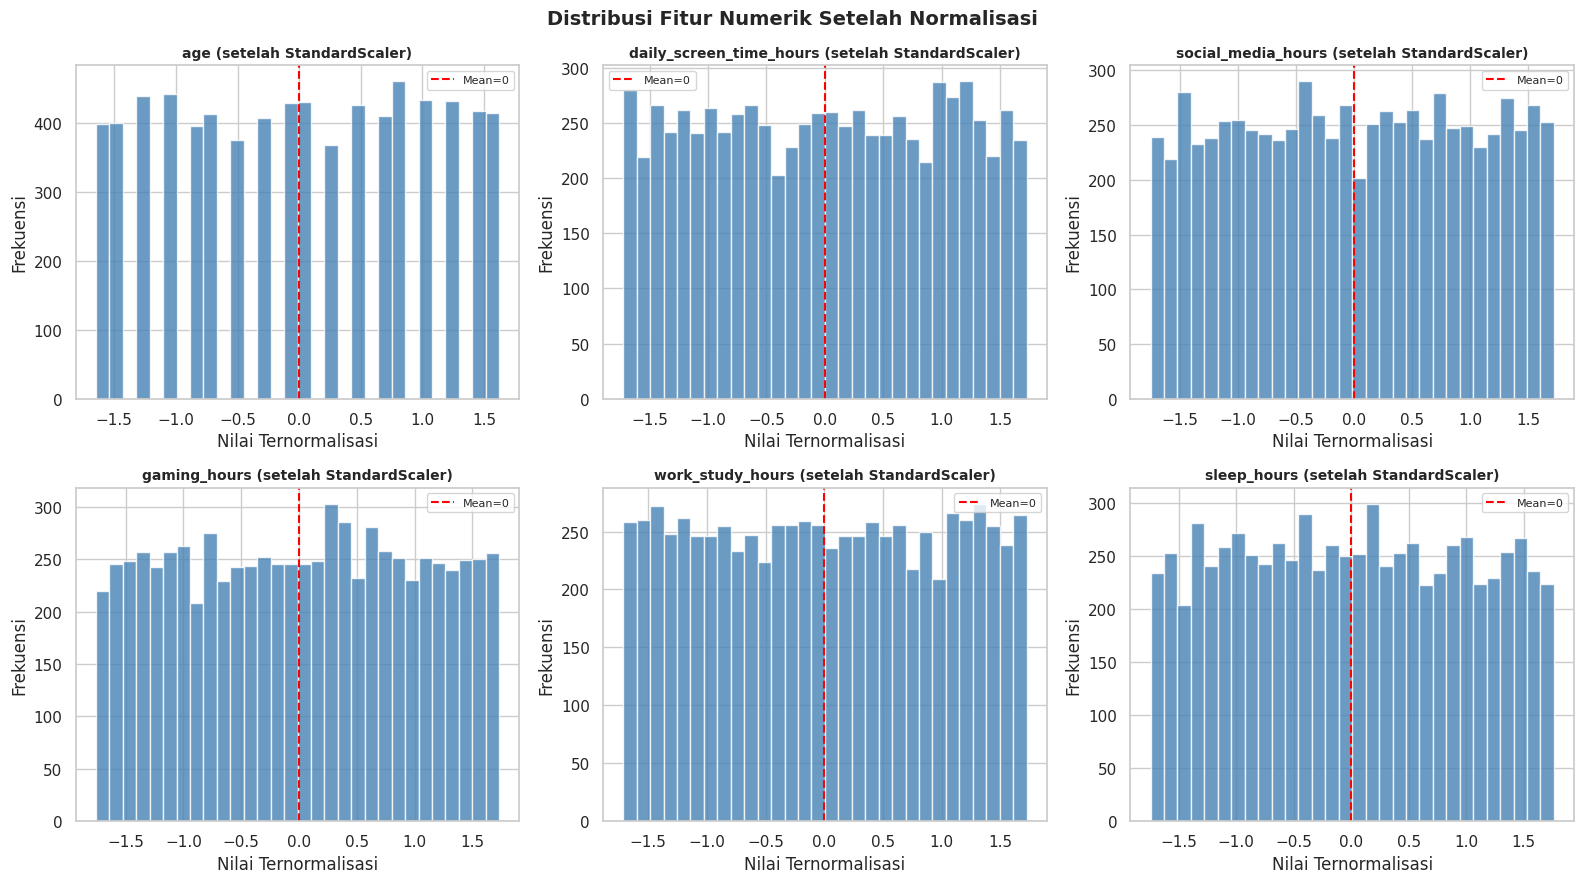

In [19]:
# Visualisasi sebelum vs sesudah normalisasi
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
sample_cols = cols_to_scale[:6]

for i, col in enumerate(sample_cols):
    row, c = divmod(i, 3)
    axes[row, c].hist(X[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[row, c].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Mean=0')
    axes[row, c].set_title(f'{col} (setelah StandardScaler)', fontsize=10, fontweight='bold')
    axes[row, c].set_xlabel('Nilai Ternormalisasi')
    axes[row, c].set_ylabel('Frekuensi')
    axes[row, c].legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik Setelah Normalisasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('normalized_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 5.5 Split Data Train dan Test

In [20]:
# Split data 80% train, 20% test dengan stratify agar distribusi kelas seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('✅ Data berhasil di-split!')
print(f'   Total data    : {len(X):,}')
print(f'   Data train    : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'   Data test     : {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nDistribusi target - Train:')
print(y_train.value_counts())
print(f'\nDistribusi target - Test:')
print(y_test.value_counts())

✅ Data berhasil di-split!
   Total data    : 7,500
   Data train    : 6,000 (80.0%)
   Data test     : 1,500 (20.0%)

Distribusi target - Train:
addicted_label
1    4246
0    1754
Name: count, dtype: int64

Distribusi target - Test:
addicted_label
1    1062
0     438
Name: count, dtype: int64


## 5.6 Simpan Data Hasil Preprocessing

In [21]:
import os

# Buat folder output
output_dir = 'smartphone_usage_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# Gabungkan X dan y lagi untuk disimpan
df_train = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
df_test  = pd.concat([X_test.reset_index(drop=True),  y_test.reset_index(drop=True)],  axis=1)
df_full_processed = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)], axis=1)

# Simpan ke CSV
df_full_processed.to_csv(f'{output_dir}/smartphone_usage_preprocessing.csv', index=False)
df_train.to_csv(f'{output_dir}/train.csv', index=False)
df_test.to_csv(f'{output_dir}/test.csv', index=False)

print('✅ Data preprocessing berhasil disimpan!')
print(f'   📁 {output_dir}/')
print(f'      - smartphone_usage_preprocessing.csv  ({len(df_full_processed):,} rows)')
print(f'      - train.csv                           ({len(df_train):,} rows)')
print(f'      - test.csv                            ({len(df_test):,} rows)')

✅ Data preprocessing berhasil disimpan!
   📁 smartphone_usage_preprocessing/
      - smartphone_usage_preprocessing.csv  (7,500 rows)
      - train.csv                           (6,000 rows)
      - test.csv                            (1,500 rows)


---
# **6. Ringkasan Preprocessing**

In [22]:
print('=' * 60)
print('       RINGKASAN PREPROCESSING - Lufthi Arief Syabana')
print('=' * 60)
print(f'Dataset  : Smartphone Usage and Addiction Analysis')
print(f'Shape raw: {df.shape}  →  Shape processed: {df_full_processed.shape}')
print()
print('Langkah-langkah yang dilakukan:')
print('  1. ✅ Drop kolom tidak relevan    : transaction_id, user_id')
print('  2. ✅ Penanganan missing values   : addiction_level → imputasi modus')
print('  3. ✅ Label Encoding (ordinal)    : stress_level, addiction_level')
print('  4. ✅ Label Encoding (binary)     : academic_work_impact')
print('  5. ✅ One-Hot Encoding (nominal)  : gender → 3 kolom baru')
print('  6. ✅ StandardScaler             : 9 kolom numerik kontinu')
print('  7. ✅ Train-Test Split (80:20)    : stratified random split')
print()
print(f'Data Train : {len(X_train):,} rows | Data Test: {len(X_test):,} rows')
print(f'Fitur      : {X.shape[1]} kolom')
print(f'Target     : addicted_label (0=Tidak Adiksi, 1=Adiksi)')
print('=' * 60)

       RINGKASAN PREPROCESSING - Lufthi Arief Syabana
Dataset  : Smartphone Usage and Addiction Analysis
Shape raw: (7500, 16)  →  Shape processed: (7500, 16)

Langkah-langkah yang dilakukan:
  1. ✅ Drop kolom tidak relevan    : transaction_id, user_id
  2. ✅ Penanganan missing values   : addiction_level → imputasi modus
  3. ✅ Label Encoding (ordinal)    : stress_level, addiction_level
  4. ✅ Label Encoding (binary)     : academic_work_impact
  5. ✅ One-Hot Encoding (nominal)  : gender → 3 kolom baru
  6. ✅ StandardScaler             : 9 kolom numerik kontinu
  7. ✅ Train-Test Split (80:20)    : stratified random split

Data Train : 6,000 rows | Data Test: 1,500 rows
Fitur      : 15 kolom
Target     : addicted_label (0=Tidak Adiksi, 1=Adiksi)
